In [1]:
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP import DP
import matplotlib.pyplot as plt
import numpy as np

In [2]:
DP = DP()
dp_parent, model_1comp, left_2comp, right_2comp = DP.extract_fits_data('./catalogs/all_catalog.fits')
dp_sample, _, _, _ = DP.extract_fits_data('./catalogs/dp_catalog.fits')
cs_df, nbcs_df, cs_nbcs_df = DP.select_nbcs(dp_parent=dp_parent, dp_sample=dp_sample)
DP.get_catalog(cs_df, model_1comp=model_1comp[cs_df.index], left_2comp=left_2comp[cs_df.index], right_2comp=right_2comp[cs_df.index], fname='./catalogs/cs_catalog.fits')
DP.get_catalog(nbcs_df, model_1comp=model_1comp[nbcs_df.index], left_2comp=left_2comp[nbcs_df.index], right_2comp=right_2comp[nbcs_df.index], fname='./catalogs/nbcs_catalog.fits')
DP.get_catalog(cs_nbcs_df, model_1comp=model_1comp[cs_nbcs_df.index], left_2comp=left_2comp[cs_nbcs_df.index], right_2comp=right_2comp[cs_nbcs_df.index], fname='./catalogs/cs-nbcs_catalog.fits')

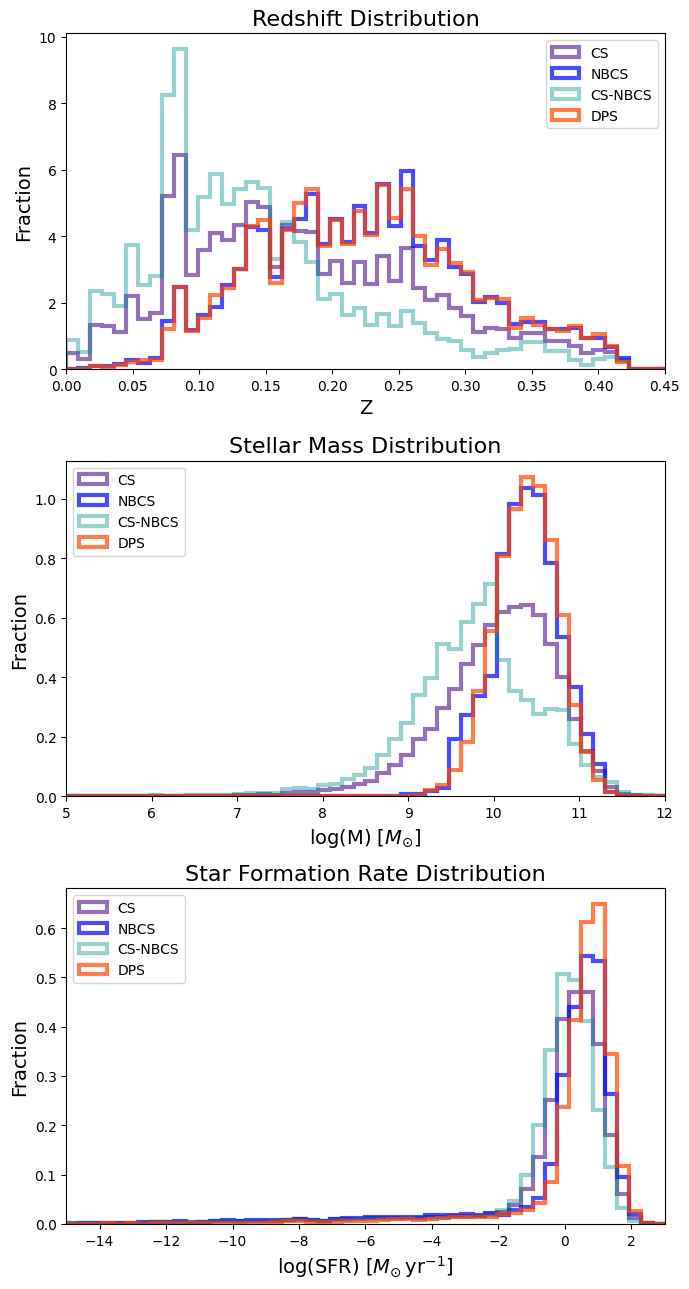

In [34]:
# Plot the distributions to verify the matching
fig, axes = plt.subplots(3, 1, figsize=(7, 13), sharey=False)

# Plot z distribution

axes[0].hist(     cs_df['Z'], bins=50, alpha=0.7, label='CS', density=True, color='rebeccapurple', histtype='step', linewidth=3, range=(0, 0.45))
axes[0].hist(   nbcs_df['Z'], bins=50, alpha=0.7, label='NBCS', density=True, color='blue', histtype='step', linewidth=3, range=(0, 0.45))
axes[0].hist(cs_nbcs_df['Z'], bins=50, alpha=0.4, label='CS-NBCS', density=True, color='darkcyan', histtype='step', linewidth=3, range=(0, 0.45))
axes[0].hist( dp_sample['Z'], bins=50, alpha=0.7, label='DPS', density=True, color='orangered', histtype='step', linewidth=3, range=(0, 0.45))
axes[0].set_title('Redshift Distribution', fontsize=16)
axes[0].set_ylabel('Fraction', fontsize=14)
axes[0].set_xlabel('Z', fontsize=14)
axes[0].set_xlim(left=0, right=0.45)
axes[0].legend()

# Plot LOGM distribution

axes[1].hist(     cs_df['LOGM'], bins=50, alpha=0.7, label='CS', density=True, color='rebeccapurple', histtype='step', linewidth=3, range=(5, 12))
axes[1].hist(   nbcs_df['LOGM'], bins=50, alpha=0.7, label='NBCS', density=True, color='blue', histtype='step', linewidth=3, range=(5, 12))
axes[1].hist(cs_nbcs_df['LOGM'], bins=50, alpha=0.4, label='CS-NBCS', density=True, color='darkcyan', histtype='step', linewidth=3, range=(5, 12))
axes[1].hist( dp_sample['LOGM'], bins=50, alpha=0.7, label='DPS', density=True, color='orangered', histtype='step', linewidth=3, range=(5, 12))
axes[1].set_title('Stellar Mass Distribution', fontsize=16)
axes[1].set_xlabel(r'log(M) $[M_{\odot}]$', fontsize=14)
axes[1].set_ylabel('Fraction', fontsize=14)
axes[1].set_xlim(left=5, right=12)
axes[1].legend()


axes[2].hist(     cs_df['LOGSFR'], bins=50, alpha=0.7, label='CS', density=True, color='rebeccapurple', histtype='step', linewidth=3, range=(-15, 3))
axes[2].hist(   nbcs_df['LOGSFR'], bins=50, alpha=0.7, label='NBCS', density=True, color='blue', histtype='step', linewidth=3, range=(-15, 3))
axes[2].hist(cs_nbcs_df['LOGSFR'], bins=50, alpha=0.4, label='CS-NBCS', density=True, color='darkcyan', histtype='step', linewidth=3, range=(-15, 3))
axes[2].hist( dp_sample['LOGSFR'], bins=50, alpha=0.7, label='DPS', density=True, color='orangered', histtype='step', linewidth=3, range=(-15, 3))
axes[2].set_title('Star Formation Rate Distribution', fontsize=16)
axes[2].set_xlabel(r'log(SFR) $[M_{\odot} \, \text{yr}^{-1}]$', fontsize=14)
axes[2].set_ylabel('Fraction', fontsize=14)
axes[2].set_xlim(left=-15, right=3)
axes[2].legend()

plt.tight_layout()
plt.savefig('./figures/Jan22/nbcs_cs_comparison.png')
plt.show()

In [4]:
print(len(dp_sample))
print(len(nbcs_df))
print(len(cs_df))
print(len(cs_nbcs_df))

18115
18021
40481
22460


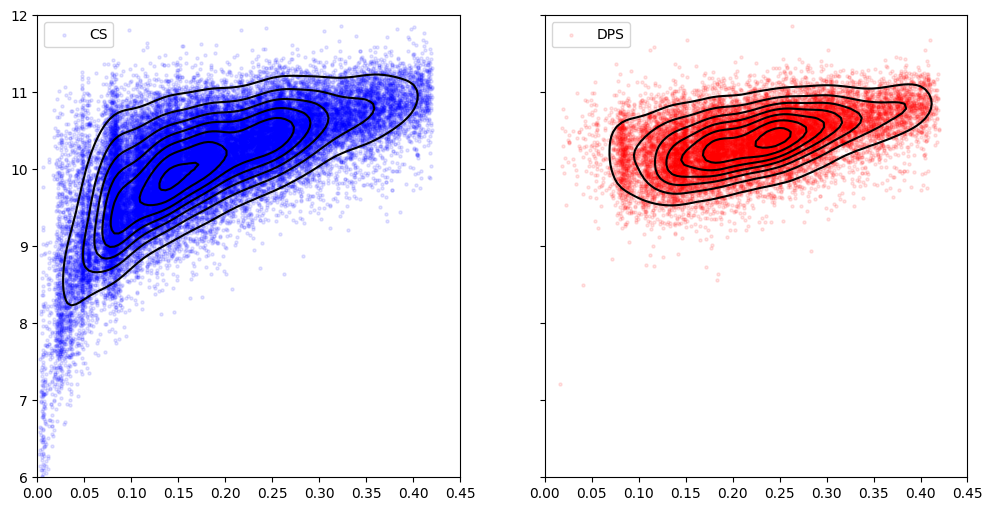

In [36]:
from scipy.stats import gaussian_kde


fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)




axes[0].scatter(cs_df['Z'], cs_df['LOGM'], color='b', s=5, label='CS', alpha=0.1)
# Create a 2D kernel density estimation
x = cs_df['Z']
y = cs_df['LOGM']
values = np.vstack([x, y])
kernel = gaussian_kde(values)

# Create a grid of points
x_grid, y_grid = np.meshgrid(np.linspace(0, 0.45, 100), np.linspace(6, 12, 100))
positions = np.vstack([x_grid.ravel(), y_grid.ravel()])
z_grid = np.reshape(kernel(positions).T, x_grid.shape)

axes[0].contour(x_grid, y_grid, z_grid, colors='black')
axes[0].set_ylim((6, 12))
axes[0].legend()


axes[1].scatter(dp_sample['Z'], dp_sample['LOGM'], color='red', s=5, label='DPS', alpha=0.1)
# Create a 2D kernel density estimation
x = dp_sample['Z']
y = dp_sample['LOGM']
values = np.vstack([x, y])
kernel = gaussian_kde(values)

# Create a grid of points
x_grid, y_grid = np.meshgrid(np.linspace(0, 0.45, 100), np.linspace(6, 12, 100))
positions = np.vstack([x_grid.ravel(), y_grid.ravel()])
z_grid = np.reshape(kernel(positions).T, x_grid.shape)

axes[1].contour(x_grid, y_grid, z_grid, colors='black')
axes[1].set_ylim((6, 12))
axes[1].legend()

plt.show()

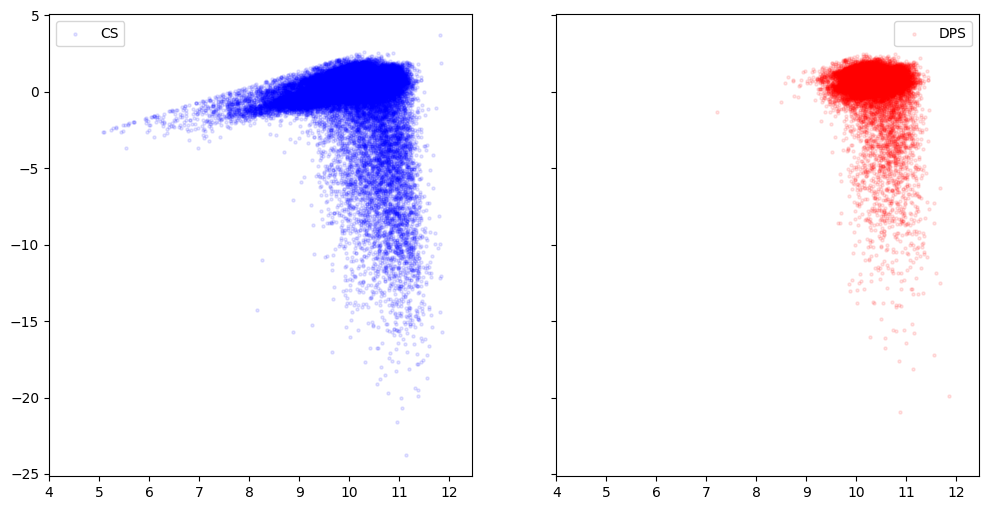

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)


axes[0].scatter(cs_df['LOGM'], cs_df['LOGSFR'], color='b', s=5, label='CS', alpha=0.1)
axes[0].set_xlim(left=4)
axes[0].legend()


axes[1].scatter(dp_sample['LOGM'], dp_sample['LOGSFR'], color='red', s=5, label='DPS', alpha=0.1)
axes[1].set_xlim(left=4)
axes[1].legend()

plt.show()